# Scale-explicit equivalent steep-area development

This notebook reads only the two derived issue #13 tables. The three windows were exposed during method development, so the plots diagnose numerical behavior and do not validate a susceptibility or hazard model.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
long = pd.read_csv(ROOT / 'data/scale_explicit_steep_area/equivalent_area_long.csv', dtype={'region': str})
diagnostics = pd.read_csv(ROOT / 'data/scale_explicit_steep_area/diagnostics.csv', dtype={'region': str})
assert len(long) == 30 and len(diagnostics) == 6
assert not any('pass' in column for column in (*long.columns, *diagnostics.columns))

In [2]:
shown = diagnostics[['region', 'stratum', 'departure_90m', 'phase_cv', 'hard_threshold_departure_90m']].copy()
display(shown.round(4))
print('Five of six paired departures decrease; Scandinavia glacier proximity increases from 0.0072 to 0.0369.')
print('These known-window diagnostics have no confirmatory pass label.')

,region,stratum,departure_90m,phase_cv,hard_threshold_departure_90m
0,03,glacier_proximity,0.0590,0.0012,0.2668
1,03,permafrost,0.0374,0.0004,0.2912
2,07,glacier_proximity,0.1343,0.0035,0.3660
3,07,permafrost,0.0708,0.0001,0.3737
4,08,glacier_proximity,0.0369,0.0011,0.0072
5,08,permafrost,0.0262,0.0002,0.1422


Five of six paired departures decrease; Scandinavia glacier proximity increases from 0.0072 to 0.0369.
These known-window diagnostics have no confirmatory pass label.


## Complete exposed-window result

The 0.8 ratio and 0.20 departure lines repeat the former convergence bounds only as visual references.

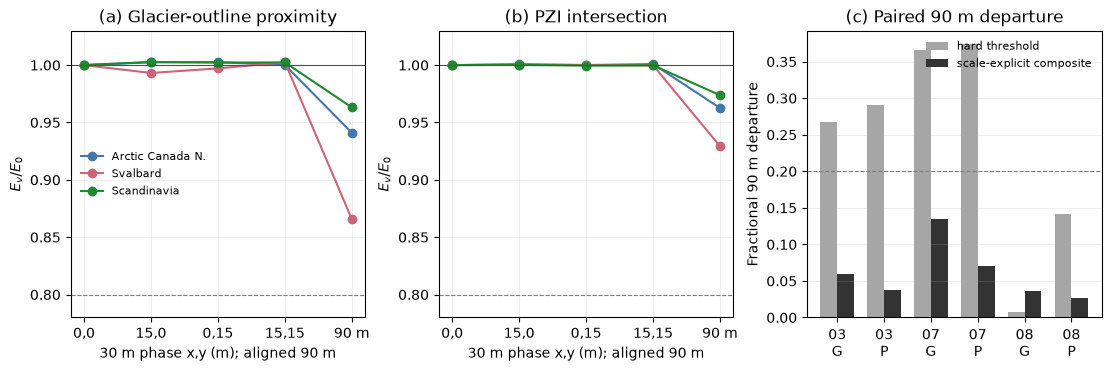

In [3]:
colors = {'03': '#4477AA', '07': '#CC6677', '08': '#228833'}
names = {'03': 'Arctic Canada N.', '07': 'Svalbard', '08': 'Scandinavia'}
variants, labels = ['p00', 'p10', 'p01', 'p11', 'r90'], ['0,0', '15,0', '0,15', '15,15', '90 m']
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for ax, stratum, title in zip(axes[:2], ['glacier_proximity', 'permafrost'], ['(a) Glacier-outline proximity', '(b) PZI intersection']):
    for region in colors:
        values = long[(long.region == region) & (long.stratum == stratum)].set_index('variant').loc[variants].area_ratio
        ax.plot(labels, values, 'o-', color=colors[region], label=names[region])
    ax.axhline(1, color='0.3', lw=0.8)
    ax.axhline(0.8, color='0.5', ls='--', lw=0.8)
    ax.set(title=title, xlabel='30 m phase x,y (m); aligned 90 m', ylabel='$E_v/E_0$', ylim=(0.78, 1.03))
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False, fontsize=8)
x = np.arange(len(diagnostics)); width = 0.36
axes[2].bar(x - width / 2, diagnostics.hard_threshold_departure_90m, width, color='0.65', label='hard threshold')
axes[2].bar(x + width / 2, diagnostics.departure_90m, width, color='0.2', label='scale-explicit composite')
axes[2].axhline(0.2, color='0.5', ls='--', lw=0.8)
axes[2].set(title='(c) Paired 90 m departure', ylabel='Fractional 90 m departure', xticks=x,
            xticklabels=[f"{row.region}\n{'G' if row.stratum == 'glacier_proximity' else 'P'}" for row in diagnostics.itertuples()])
axes[2].legend(frameon=False, fontsize=8); axes[2].grid(axis='y', alpha=0.2)
for suffix in ('png', 'pdf'):
    fig.savefig(ROOT / f'figures/scale_explicit_steep_area.{suffix}', dpi=220 if suffix == 'png' else None, bbox_inches='tight')
plt.show()